# Customer Review Sentiment Analysis

A model that reads a product review and decides whether it's positive, negative, or neutral, the kind of tool a brand or customer insights team would use to track sentiment at scale instead of reading every review by hand.


## The problem

A popular product can get thousands of reviews a month. No marketing team has time to read all of them, but ignoring them means missing real signals: a feature people love, a defect everyone's complaining about, a shift in mood after a product update.

Sentiment analysis automates the first pass. Instead of a person reading every review, a model scans each one and tags it positive, negative, or neutral. A human still needs to read the negative ones closely, but now they know where to look instead of starting from a pile of thousands.

We're using a real dataset here: just over 3,000 verified Amazon reviews of Alexa devices (Echo, Echo Dot, Firestick, and similar products), each with a 1 to 5 star rating and the review text itself.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [5]:
df = pd.read_csv('amazon_alexa.csv', sep='\t')

In [8]:
df = df.dropna(subset=['verified_reviews']).reset_index(drop=True)
print(f' Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

 Shape: 3,149 rows x 5 columns


,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


## Exploring the data

The dataset gives us a star rating, not a sentiment label directly, so the first step is turning ratings into the three classes we actually care about:

- 1 or 2 stars → **negative**
- 3 stars → **neutral**
- 4 or 5 stars → **positive**

Before building anything, it's worth looking at how these classes are distributed, and whether review length differs by sentiment.

In [9]:
def rating_to_sentiment(rating):
    if rating <= 2:
        return 'negative'
    elif rating == 3:
        return 'neutral'
    else:
        return 'positive'

df['sentiment'] = df['rating'].apply(rating_to_sentiment)

print(df['sentiment'].value_counts())
print()
print(df['sentiment'].value_counts(normalize=True).round(3))

sentiment
positive    2741
negative     256
neutral      152
Name: count, dtype: int64

sentiment
positive    0.870
negative    0.081
neutral     0.048
Name: proportion, dtype: float64


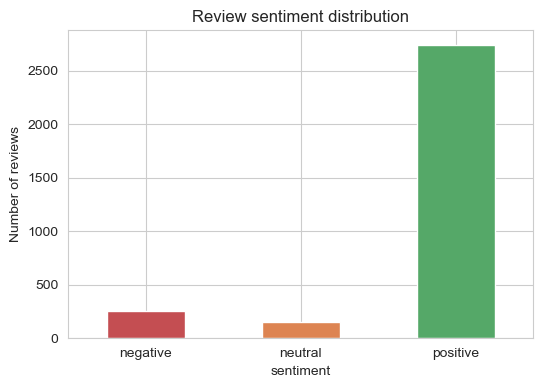

In [10]:
plt.figure(figsize=(6,4))
df['sentiment'].value_counts().reindex(['negative', 'neutral', 'positive']).plot(
    kind='bar', color=['#C44E52', '#DD8452', '#55A868']
)
plt.title('Review sentiment distribution')
plt.ylabel('Number of reviews')
plt.xticks(rotation=0)
plt.show()

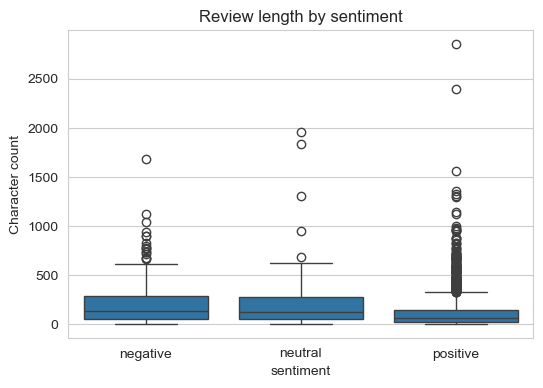

In [11]:
df['review_length'] = df['verified_reviews'].str.len()

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='sentiment', y='review_length', order=['negative', 'neutral', 'positive'])
plt.title('Review length by sentiment')
plt.ylabel('Character count')
plt.show()

**Insight**

**What we're seeing:** the classes are heavily imbalanced, the vast majority of reviews are positive, which makes sense for a popular product line where most buyers are satisfied enough to not return it. That imbalance is going to matter later. Negative reviews also tend to run a bit longer on average, which is a pattern that shows up across review platforms: people write more when they're frustrated and want to explain exactly what went wrong.

## How does a computer read text?

 A review like "the sound quality is amazing but the setup was a nightmare" isn't a number. Before any model can learn from it, the text has to be converted into something numeric, and that conversion is really the heart of NLP.

A few building blocks:

- **Tokenization** - splitting a sentence into individual words or pieces. "I love this" becomes `["I", "love", "this"]`. Sounds trivial, but punctuation, contractions, and typos all make it messier than it looks.
- **Stop words** - common words like "the", "is", and "a" that show up everywhere and usually carry little meaning on their own. Many NLP pipelines remove them, though it's not always the right call (more on that below).
- **The negation problem** - "good" and "not good" are nearly opposite in meaning but share almost all the same words. A model that just counts word occurrences without any sense of order can completely miss this, which is one of the real limitations of the approach we're using in this project.

There's also a design choice worth naming directly: a basic word-counting approach has no concept of word order or context. 

## TF-IDF: turning words into numbers

TF-IDF stands for **Term Frequency, Inverse Document Frequency**. That sounds technical, but the idea is intuitive: a word matters more for telling reviews apart if it shows up a lot in one review, but not in most reviews overall.

Think about the word "the." It shows up constantly, in nearly every review, so it tells you almost nothing about whether a specific review is positive or negative. Now think about the word "defective." It shows up rarely, but when it does, it's a strong signal. TF-IDF gives "defective" a much higher score than "the," even though "the" might appear more often in any single review.

- **Term Frequency (TF)**: how often a word appears in this specific review
- **Inverse Document Frequency (IDF)**: a penalty for words that appear in lots of reviews, since common words are less useful for distinguishing one review from another

Multiply the two together and every word gets a score that reflects how distinctive it is for that particular review. The result is a big table: one row per review, one column per word, with TF-IDF scores filling the cells. That table is what we actually feed into the model.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['verified_reviews']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [13]:
# max_features caps the vocabulary size, ngram_range=(1,2) lets the model see
# two-word phrases too ("not good"), which helps a little with the negation problem
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2
)


In [14]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Vocabulary size:", len(vectorizer.vocabulary_))
print("Training matrix shape:", X_train_tfidf.shape)

Vocabulary size: 5000
Training matrix shape: (2519, 5000)


In [15]:
# A quick sanity check: which words carry the most weight overall?
feature_names = np.array(vectorizer.get_feature_names_out())
avg_tfidf = np.asarray(X_train_tfidf.mean(axis=0)).ravel()
top_words = feature_names[np.argsort(avg_tfidf)[-15:]]
print("Some of the most distinctive terms in the vocabulary:")
print(list(top_words))

Some of the most distinctive terms in the vocabulary:
['works great', 'just', 'sound', 'set', 'good', 'product', 'music', 'use', 'alexa', 'easy', 'like', 'works', 'echo', 'great', 'love']


## Building the model

With the text converted into TF-IDF scores, the modeling step itself is almost an afterthought, which is the point. Most of the real work in NLP is in how you represent the text, not which algorithm you throw at it afterward.

We're using **logistic regression**, kept deliberately simple. The goal of this project is to understand the text processing pipeline clearly. We'll also handle the class imbalance we saw earlier with class weights.

In [16]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

clf.fit(X_train_tfidf, y_train)
print("Model trained.")

Model trained.


## Evaluating the model

Accuracy alone would be misleading here too, since positive reviews dominate the dataset. We'll look at precision and recall per class, and the confusion matrix specifically, since the most interesting mistakes a sentiment model makes are usually between neutral and positive, not between positive and negative (those two are rarely confused, since the language is so different).

In [17]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = clf.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.56      0.67      0.61        51
     neutral       0.30      0.52      0.38        31
    positive       0.96      0.91      0.93       548

    accuracy                           0.87       630
   macro avg       0.61      0.70      0.64       630
weighted avg       0.90      0.87      0.88       630



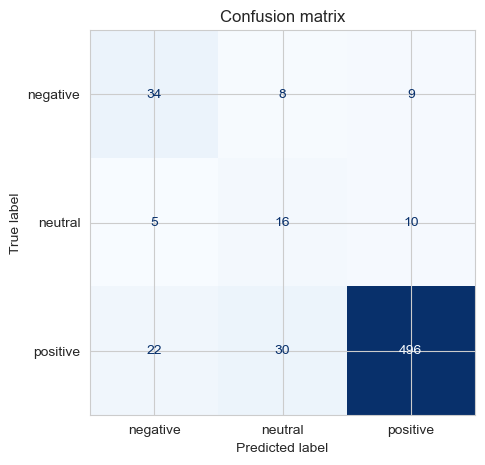

In [18]:
labels = ['negative', 'neutral', 'positive']
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion matrix')
plt.show()

**Insight**

Look at where the model actually gets confused. Most of the mistakes happen between **neutral** and **positive**, which lines up with what we'd expect: a 3-star review and a 4-star review are often written in genuinely similar language ("it's fine, does the job, nothing special" vs. "pretty good, would recommend"), so this is a harder distinction even for a person skimming quickly. Negative reviews are rarely confused with positive ones, since angry, disappointed language tends to look very different from happy language. That asymmetry is worth remembering: not all misclassifications are equally bad, and in this case, the model's mistakes are concentrated in the lowest-stakes place.

In [19]:
# Which words pushed the model toward positive vs negative predictions the most?
# Logistic regression gives us a coefficient per word per class, which doubles as
# a built-in explanation of what the model picked up on.
feature_names = np.array(vectorizer.get_feature_names_out())

for sentiment_class in ['negative', 'positive']:
    class_idx = list(clf.classes_).index(sentiment_class)
    coefs = clf.coef_[class_idx]
    top_idx = np.argsort(coefs)[-10:]
    print(f"Top words pushing toward '{sentiment_class}':")
    print(list(feature_names[top_idx]))
    print()

Top words pushing toward 'negative':
['terrible', 'try', 'money', 'slow', 'working', 'return', 'refurbished', 'poor', 'amazon', 'didn']

Top words pushing toward 'positive':
['best', 'perfect', 'learning', 'amazing', 'fun', 'works', 'music', 'easy', 'great', 'love']



## What this means for a brand or marketing team

Picture this plugged into a real review pipeline. Every new review gets tagged automatically the moment it comes in, no waiting for a person to read it. A dashboard tracks the share of negative reviews week over week, so a sudden spike after a product update gets caught fast instead of discovered a month later in a quarterly report.

The negative reviews still get read by a human, but now it's a focused queue of maybe 50 reviews instead of 3,000. The model's coefficients also double as a lightweight insight tool on their own: looking at which words push predictions toward negative gives a marketing team an early read on recurring complaints (connectivity issues, setup problems, and so on) without anyone having to manually tag a single review.

## What this demonstrates

NLP fundamentals: tokenization, stop words, and the negation problem that motivates more advanced techniques. TF-IDF as a way to turn text into numbers a model can use, including why it weighs rare, distinctive words more heavily than common ones. And reading a confusion matrix to understand not just how often a model is wrong, but where it's wrong and why that pattern makes sense.